# Synthetic Patient Utilization & Outcomes Analysis

**Data:** Synthea synthetic patient records (1,120 patients). No real patient data or PHI.
**Tools:** Python, SQLite, SQL, pandas, matplotlib

This notebook works through a full analysis in four parts:

1. **Load and validate:** load six CSV files into SQLite and check data quality
2. **Profile:** understand what the data contains and set the analysis rules
3. **Analysis:** 14 questions, from basic counts to window functions
4. **Key findings**

All results describe a **synthetic** population. They show patterns, not causes, and are not estimates for any real population.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

RAW = Path("data/raw")
DB = Path("data/synthea.db")
Path("docs/images").mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
NAVY, GREY, TEAL = "#1f4e79", "#9aa7b4", "#2a9d8f"

def save(name):
    """Save the current chart to docs/images and display it."""
    plt.tight_layout()
    plt.savefig(f"docs/images/{name}.png", bbox_inches="tight")
    plt.show()

---
## Part 1 · Load and Validate

`raw CSVs (untouched)` → `load into SQLite` → `validate` → `clean views for analysis (Part 2)`

### 1. Load

The raw CSVs stay unchanged in `data/raw/`. The database is rebuilt from them each time this notebook runs, so every result can be reproduced from the source files.

Synthea generates fake SSNs, driver's license and passport numbers, names, street addresses, and coordinates. None of them are needed for this analysis, so they are dropped before loading. The data is synthetic, but this is the same minimum-necessary habit I would follow with real PHI.

In [2]:
IDENTIFIER_COLUMNS = [
    "SSN", "DRIVERS", "PASSPORT", "PREFIX", "FIRST", "MIDDLE", "LAST",
    "SUFFIX", "MAIDEN", "BIRTHPLACE", "ADDRESS", "ZIP", "LAT", "LON",
]

TABLES = ["patients", "encounters", "conditions", "observations", "procedures", "medications"]

DB.unlink(missing_ok=True)
con = sqlite3.connect(DB)

load_log = []
for table in TABLES:
    df = pd.read_csv(RAW / f"{table}.csv", low_memory=False)
    raw_rows = len(df)
    if table == "patients":
        df = df.drop(columns=[c for c in IDENTIFIER_COLUMNS if c in df.columns])
    df.to_sql(table, con, index=False)
    load_log.append({"table": table, "csv_rows": raw_rows, "columns_loaded": df.shape[1]})

def q(sql):
    """Run a SQL query and return the result as a DataFrame."""
    return pd.read_sql(sql, con)

pd.DataFrame(load_log)

,table,csv_rows,columns_loaded
0,patients,1120,14
1,encounters,62323,15
2,conditions,39176,7
3,observations,805560,9
4,procedures,173267,10
5,medications,52434,13


#### Reconcile: rows in the database vs rows in the CSVs

If any number differs, the load dropped or duplicated records.

In [3]:
db_counts = q("""
    SELECT 'patients' AS "table", COUNT(*) AS db_rows FROM patients
    UNION ALL SELECT 'encounters',   COUNT(*) FROM encounters
    UNION ALL SELECT 'conditions',   COUNT(*) FROM conditions
    UNION ALL SELECT 'observations', COUNT(*) FROM observations
    UNION ALL SELECT 'procedures',   COUNT(*) FROM procedures
    UNION ALL SELECT 'medications',  COUNT(*) FROM medications
""")
recon = pd.DataFrame(load_log)[["table", "csv_rows"]].merge(db_counts, on="table")
recon["match"] = recon["csv_rows"] == recon["db_rows"]
recon

,table,csv_rows,db_rows,match
0,patients,1120,1120,True
1,encounters,62323,62323,True
2,conditions,39176,39176,True
3,observations,805560,805560,True
4,procedures,173267,173267,True
5,medications,52434,52434,True


#### Indexes on join keys

Every analysis joins on patient and encounter IDs. Indexes keep those joins fast on the 805,000-row observations table.

In [4]:
con.executescript("""
    CREATE UNIQUE INDEX ix_patients_id   ON patients(Id);
    CREATE UNIQUE INDEX ix_encounters_id ON encounters(Id);
    CREATE INDEX ix_enc_patient   ON encounters(PATIENT);
    CREATE INDEX ix_enc_start     ON encounters(START);
    CREATE INDEX ix_cond_patient  ON conditions(PATIENT);
    CREATE INDEX ix_cond_enc      ON conditions(ENCOUNTER);
    CREATE INDEX ix_obs_enc       ON observations(ENCOUNTER);
    CREATE INDEX ix_proc_enc      ON procedures(ENCOUNTER);
    CREATE INDEX ix_med_enc       ON medications(ENCOUNTER);
""")
print("Indexes created. The unique indexes also confirm there are no duplicate patient or encounter IDs.")

Indexes created. The unique indexes also confirm there are no duplicate patient or encounter IDs.


### 2. Validation checks

Each check counts the rows that break a rule. Checks are grouped by data-quality dimension:

| Dimension | Question it answers |
|---|---|
| Uniqueness | Is each record recorded once? |
| Completeness | Are required values present? |
| Validity | Are values within allowed ranges? |
| Consistency | Do related records agree with each other? |
| Timeliness | Are events dated within a possible window? |

Status meanings: **PASS** no problems · **FAIL** integrity problem · **WARN** real but explainable, handled in analysis · **INFO** context only.

In [5]:
CHECKS = [
    # (id, dimension, description, severity if rows found, SQL returning a single count)
    ("V01", "Uniqueness", "Duplicate patient IDs", "FAIL",
     "SELECT COUNT(*) FROM (SELECT Id FROM patients GROUP BY Id HAVING COUNT(*) > 1)"),
    ("V02", "Uniqueness", "Duplicate encounter IDs", "FAIL",
     "SELECT COUNT(*) FROM (SELECT Id FROM encounters GROUP BY Id HAVING COUNT(*) > 1)"),

    ("V03", "Completeness", "Encounters missing START, PATIENT or ENCOUNTERCLASS", "FAIL",
     "SELECT COUNT(*) FROM encounters WHERE START IS NULL OR PATIENT IS NULL OR ENCOUNTERCLASS IS NULL"),
    ("V04", "Completeness", "Encounters missing STOP", "WARN",
     "SELECT COUNT(*) FROM encounters WHERE STOP IS NULL"),
    ("V05", "Completeness", "Observations with no encounter link", "WARN",
     "SELECT COUNT(*) FROM observations WHERE ENCOUNTER IS NULL"),

    ("V06", "Validity", "Negative claim cost or payer coverage", "FAIL",
     "SELECT COUNT(*) FROM encounters WHERE TOTAL_CLAIM_COST < 0 OR PAYER_COVERAGE < 0"),
    ("V07", "Validity", "Payer coverage greater than claim cost", "FAIL",
     "SELECT COUNT(*) FROM encounters WHERE PAYER_COVERAGE > TOTAL_CLAIM_COST"),
    ("V08", "Validity", "Encounter STOP before START", "FAIL",
     "SELECT COUNT(*) FROM encounters WHERE julianday(STOP) < julianday(START)"),

    ("V09", "Consistency", "Encounters pointing to a patient that does not exist", "FAIL",
     "SELECT COUNT(*) FROM encounters e WHERE NOT EXISTS (SELECT 1 FROM patients p WHERE p.Id = e.PATIENT)"),
    ("V10", "Consistency", "Conditions pointing to an encounter that does not exist", "FAIL",
     "SELECT COUNT(*) FROM conditions c WHERE c.ENCOUNTER IS NOT NULL AND NOT EXISTS (SELECT 1 FROM encounters e WHERE e.Id = c.ENCOUNTER)"),
    ("V11", "Consistency", "Procedures pointing to an encounter that does not exist", "FAIL",
     "SELECT COUNT(*) FROM procedures x WHERE x.ENCOUNTER IS NOT NULL AND NOT EXISTS (SELECT 1 FROM encounters e WHERE e.Id = x.ENCOUNTER)"),
    ("V12", "Consistency", "Medications pointing to an encounter that does not exist", "FAIL",
     "SELECT COUNT(*) FROM medications x WHERE x.ENCOUNTER IS NOT NULL AND NOT EXISTS (SELECT 1 FROM encounters e WHERE e.Id = x.ENCOUNTER)"),
    ("V13", "Consistency", "Observations pointing to an encounter that does not exist", "FAIL",
     "SELECT COUNT(*) FROM observations x WHERE x.ENCOUNTER IS NOT NULL AND NOT EXISTS (SELECT 1 FROM encounters e WHERE e.Id = x.ENCOUNTER)"),
    ("V14", "Consistency", "Condition belongs to a different patient than its encounter", "FAIL",
     "SELECT COUNT(*) FROM conditions c JOIN encounters e ON e.Id = c.ENCOUNTER WHERE c.PATIENT <> e.PATIENT"),
    ("V15", "Consistency", "Procedure belongs to a different patient than its encounter", "FAIL",
     "SELECT COUNT(*) FROM procedures x JOIN encounters e ON e.Id = x.ENCOUNTER WHERE x.PATIENT <> e.PATIENT"),

    ("V16", "Timeliness", "Encounters before the patient's birth date", "FAIL",
     "SELECT COUNT(*) FROM encounters e JOIN patients p ON p.Id = e.PATIENT WHERE date(e.START) < p.BIRTHDATE"),
    ("V17", "Timeliness", "Encounters after the patient's death date", "FAIL",
     "SELECT COUNT(*) FROM encounters e JOIN patients p ON p.Id = e.PATIENT WHERE p.DEATHDATE IS NOT NULL AND date(e.START) > p.DEATHDATE"),
    ("V18", "Timeliness", "Encounters dated in the future", "WARN",
     "SELECT COUNT(*) FROM encounters WHERE date(START) > date('now')"),

    ("V19", "Consistency", "Per-patient encounter counts do not add up to the table total", "FAIL",
     """SELECT ABS((SELECT COUNT(*) FROM encounters)
                  - (SELECT SUM(n) FROM (SELECT COUNT(e.Id) AS n FROM patients p
                                         LEFT JOIN encounters e ON e.PATIENT = p.Id GROUP BY p.Id)))"""),
]

def run_checks(checks):
    rows = []
    for cid, dim, desc, severity, sql in checks:
        n = con.execute(sql).fetchone()[0]
        status = "PASS" if n == 0 else severity
        rows.append({"id": cid, "dimension": dim, "check": desc, "rows_flagged": n, "status": status})
    return pd.DataFrame(rows)

results = run_checks(CHECKS)
results

,id,dimension,check,rows_flagged,status
0,V01,Uniqueness,Duplicate patient IDs,0,PASS
1,V02,Uniqueness,Duplicate encounter IDs,0,PASS
2,V03,Completeness,"Encounters missing START, PATIENT or ENCOUNTERCLASS",0,PASS
3,V04,Completeness,Encounters missing STOP,0,PASS
4,V05,Completeness,Observations with no encounter link,31200,WARN
5,V06,Validity,Negative claim cost or payer coverage,0,PASS
6,V07,Validity,Payer coverage greater than claim cost,0,PASS
7,V08,Validity,Encounter STOP before START,0,PASS
8,V09,Consistency,Encounters pointing to a patient that does not exist,0,PASS
9,V10,Consistency,Conditions pointing to an encounter that does not exist,0,PASS


In [6]:
results["status"].value_counts()

status
PASS    16
WARN     2
FAIL     1
Name: count, dtype: int64

### 3. Investigating what the checks flagged

#### V17: encounters after death

A patient can't receive care after death, so this looked like a real integrity error. Grouping the flagged rows by description shows what they are:

In [7]:
q("""
    SELECT e.DESCRIPTION,
           e.ENCOUNTERCLASS,
           COUNT(*)                                             AS encounters,
           MIN(julianday(date(e.START)) - julianday(p.DEATHDATE)) AS min_days_after_death,
           MAX(julianday(date(e.START)) - julianday(p.DEATHDATE)) AS max_days_after_death
    FROM encounters e
    JOIN patients p ON p.Id = e.PATIENT
    WHERE p.DEATHDATE IS NOT NULL
      AND date(e.START) > p.DEATHDATE
    GROUP BY e.DESCRIPTION, e.ENCOUNTERCLASS
""")

,DESCRIPTION,ENCOUNTERCLASS,encounters,min_days_after_death,max_days_after_death
0,Death Certification,wellness,108,1.0,14.0


Every flagged row is a **Death Certification** record, filed under the *wellness* encounter class, 1 to 14 days after death. This is paperwork, not care delivered. Left in, it would be counted as a wellness visit.

**Decision:** exclude all Death Certification records from utilization analysis. How many are there in total, including those dated on the day of death?

In [8]:
q("""
    SELECT COUNT(*) AS death_certification_records,
           (SELECT COUNT(*) FROM patients WHERE DEATHDATE IS NOT NULL) AS deceased_patients
    FROM encounters
    WHERE DESCRIPTION = 'Death Certification'
""")

,death_certification_records,deceased_patients
0,113,120


#### V18: future-dated encounter

In [9]:
q("""
    SELECT Id, date(START) AS start_date, ENCOUNTERCLASS, DESCRIPTION
    FROM encounters
    WHERE date(START) > date('now')
""")

,Id,start_date,ENCOUNTERCLASS,DESCRIPTION
0,a0e39ffb-8a34-f502-3141-929a644cb365,2026-10-04,wellness,Death Certification


The single future-dated record is also a Death Certification, so the same exclusion removes it.

#### V05: observations with no encounter

In [10]:
q("""
    SELECT DESCRIPTION, COUNT(*) AS rows, COUNT(DISTINCT PATIENT) AS patients
    FROM observations
    WHERE ENCOUNTER IS NULL
    GROUP BY DESCRIPTION
""")

,DESCRIPTION,rows,patients
0,DALY,10400,1048
1,QALY,10400,1048
2,QOLS,10400,1048


These are yearly patient-level quality-of-life scores (QALY, DALY, QOLS), not broken links. They are recorded against the patient, not a visit. They are not used in this analysis.

#### Revised checks

V17 is rewritten to exclude Death Certification, so it tests what it was meant to test: care recorded after death. A new check (V20) tracks the Death Certification records separately.

In [11]:
REVISED = [c for c in CHECKS if c[0] != "V17"] + [
    ("V17", "Timeliness", "Care encounters after the patient's death date (excl. Death Certification)", "FAIL",
     """SELECT COUNT(*) FROM encounters e JOIN patients p ON p.Id = e.PATIENT
        WHERE p.DEATHDATE IS NOT NULL AND date(e.START) > p.DEATHDATE
          AND e.DESCRIPTION <> 'Death Certification'"""),
    ("V20", "Validity", "Death Certification records filed as encounters", "WARN",
     "SELECT COUNT(*) FROM encounters WHERE DESCRIPTION = 'Death Certification'"),
]
final_results = run_checks(sorted(REVISED, key=lambda c: c[0]))
final_results

,id,dimension,check,rows_flagged,status
0,V01,Uniqueness,Duplicate patient IDs,0,PASS
1,V02,Uniqueness,Duplicate encounter IDs,0,PASS
2,V03,Completeness,"Encounters missing START, PATIENT or ENCOUNTERCLASS",0,PASS
3,V04,Completeness,Encounters missing STOP,0,PASS
4,V05,Completeness,Observations with no encounter link,31200,WARN
5,V06,Validity,Negative claim cost or payer coverage,0,PASS
6,V07,Validity,Payer coverage greater than claim cost,0,PASS
7,V08,Validity,Encounter STOP before START,0,PASS
8,V09,Consistency,Encounters pointing to a patient that does not exist,0,PASS
9,V10,Consistency,Conditions pointing to an encounter that does not exist,0,PASS


### 4. Why joins need care: row multiplication

Joining encounters to a child table creates one row per child record. Summing encounter cost after that join counts the same encounter many times. The fix is to aggregate the child table first, then join.

In [12]:
q("""
    SELECT 'encounters only' AS step,
           COUNT(*) AS rows, ROUND(SUM(TOTAL_CLAIM_COST)) AS summed_cost
    FROM encounters
    UNION ALL
    SELECT 'encounters JOIN procedures (wrong)',
           COUNT(*), ROUND(SUM(e.TOTAL_CLAIM_COST))
    FROM encounters e JOIN procedures p ON p.ENCOUNTER = e.Id
    UNION ALL
    SELECT 'procedures counted first, then joined (right)',
           COUNT(*), ROUND(SUM(e.TOTAL_CLAIM_COST))
    FROM encounters e
    LEFT JOIN (SELECT ENCOUNTER, COUNT(*) AS n FROM procedures GROUP BY ENCOUNTER) pc
           ON pc.ENCOUNTER = e.Id
""")

,step,rows,summed_cost
0,encounters only,62323,1.994162e+08
1,encounters JOIN procedures (wrong),173267,1.429315e+09
2,"procedures counted first, then joined (right)",62323,1.994162e+08


The naive join inflates total cost about sevenfold. Every analysis in Part 3 aggregates child tables before joining them to encounters.

### Part 1 summary

- All six tables loaded with row counts matching the source CSVs.
- No duplicate keys, orphan records, invalid costs, or impossible dates.
- Two data behaviors need handling in the analysis:
  1. **Death Certification** records are filed as wellness encounters after death. **Excluded.**
  2. **QALY/DALY/QOLS** scores have no encounter link. **Not used.**

---
## Part 2 · Profile the Data and Set Analysis Rules

Before answering any question, look at what the data actually contains: coverage by year, category values, conditions, and cost patterns. The rules at the end become two views that every query in Part 3 uses.

### 1. Cohort size

In [13]:
q("""
    SELECT CASE WHEN DEATHDATE IS NULL THEN 'living' ELSE 'deceased' END AS status,
           COUNT(*) AS patients
    FROM patients
    GROUP BY status
""")

,status,patients
0,deceased,120
1,living,1000


Synthea's `-p 1000` setting controls the number of **living** patients. Deceased patients are generated in addition, which is why the total is 1,120.

### 2. Coverage by year

Synthea simulates full lifetimes, so encounters go back decades. The question is where the detailed record starts.

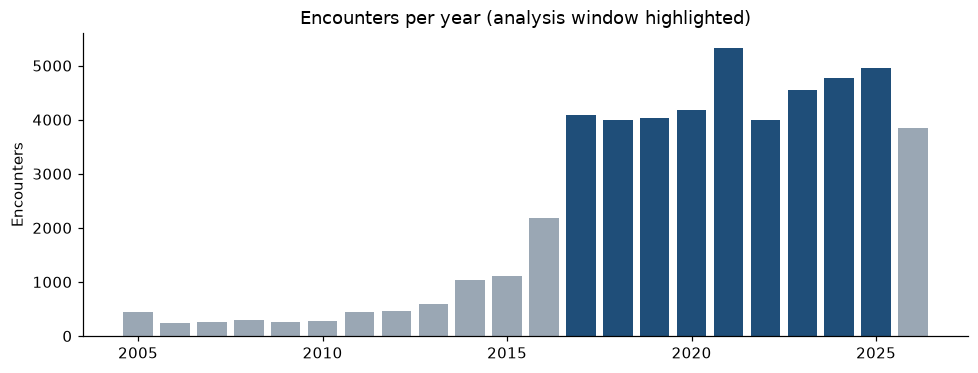

,91,92,93,94,95,96,97,98,99,100,101,102
year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
encounters,1117,2185,4081,3998,4034,4188,5334,3990,4553,4767,4957,3838


In [14]:
by_year = q("""
    SELECT CAST(substr(START, 1, 4) AS INTEGER) AS year, COUNT(*) AS encounters
    FROM encounters
    WHERE DESCRIPTION <> 'Death Certification'
    GROUP BY year
    ORDER BY year
""")

recent = by_year[by_year["year"] >= 2005]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(recent["year"], recent["encounters"], color="#9aa7b4")
ax.bar(recent.query("2017 <= year <= 2025")["year"],
       recent.query("2017 <= year <= 2025")["encounters"], color="#1f4e79")
ax.set_title("Encounters per year (analysis window highlighted)")
ax.set_ylabel("Encounters")
plt.tight_layout()
plt.savefig("docs/images/encounters_by_year.png", bbox_inches="tight")
plt.show()

recent.tail(12).T

Volume roughly doubles from 2016 to 2017 and then stays in a stable band. Before 2017 the record is sparse, and 2026 is a partial year.

**Decision 1: analyze full calendar years 2017–2025.**

### 3. What the categorical fields contain

In [15]:
q("""
    SELECT ENCOUNTERCLASS,
           COUNT(*) AS encounters,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM encounters
    WHERE DESCRIPTION <> 'Death Certification'
    GROUP BY ENCOUNTERCLASS
    ORDER BY encounters DESC
""")

,ENCOUNTERCLASS,encounters,pct
0,ambulatory,34124,54.9
1,wellness,13229,21.3
2,outpatient,8139,13.1
3,urgentcare,2817,4.5
4,emergency,2280,3.7
5,inpatient,1029,1.7
6,home,202,0.3
7,snf,133,0.2
8,hospice,129,0.2
9,virtual,128,0.2


Ambulatory and wellness visits make up about three quarters of all encounters. Emergency and inpatient together are about 5%. Headline numbers that pool every class will mostly reflect routine scheduled care, so the analysis separates **acute care** (emergency + inpatient) from the rest.

**Decision 2: report utilization by encounter class; treat emergency + inpatient as "acute". Urgent care stays separate.**

In [16]:
demo = {
    "gender":    q("SELECT GENDER    AS value, COUNT(*) AS patients FROM patients GROUP BY 1 ORDER BY 2 DESC"),
    "race":      q("SELECT RACE      AS value, COUNT(*) AS patients FROM patients GROUP BY 1 ORDER BY 2 DESC"),
    "ethnicity": q("SELECT ETHNICITY AS value, COUNT(*) AS patients FROM patients GROUP BY 1 ORDER BY 2 DESC"),
}
pd.concat(demo, names=["field"]).droplevel(1)

,value,patients
field,,
gender,F,577
gender,M,543
race,white,853
race,black,156
race,asian,73
race,other,18
race,native,10
race,hawaiian,10
ethnicity,nonhispanic,913


### 4. Conditions

The condition table holds SNOMED CT codes. Grouping by the suffix in the description shows what kinds of entries it contains.

In [17]:
q("""
    SELECT CASE
             WHEN DESCRIPTION LIKE '%(disorder)'  THEN 'disorder'
             WHEN DESCRIPTION LIKE '%(finding)'   THEN 'finding'
             WHEN DESCRIPTION LIKE '%(situation)' THEN 'situation'
             ELSE 'other'
           END AS entry_type,
           COUNT(*) AS rows,
           COUNT(DISTINCT DESCRIPTION) AS distinct_conditions
    FROM conditions
    GROUP BY entry_type
    ORDER BY rows DESC
""")

,entry_type,rows,distinct_conditions
0,finding,17624,59
1,disorder,12726,177
2,situation,8524,19
3,other,302,8


In [18]:
q("""
    SELECT DESCRIPTION, COUNT(DISTINCT PATIENT) AS patients
    FROM conditions
    WHERE DESCRIPTION LIKE '%(finding)'
    GROUP BY DESCRIPTION
    ORDER BY patients DESC
    LIMIT 10
""")

,DESCRIPTION,patients
0,Stress (finding),853
1,Full-time employment (finding),838
2,Part-time employment (finding),669
3,Social isolation (finding),576
4,Limited social contact (finding),553
5,Received higher education (finding),502
6,Body mass index 30+ - obesity (finding),492
7,Not in labor force (finding),491
8,Victim of intimate partner abuse (finding),448
9,Prediabetes (finding),394


Many "findings" are social circumstances such as employment and education, not clinical diagnoses. Mixing them into a "most common conditions" list would be misleading.

**Decision 3: condition analyses use entries marked `(disorder)`. Chronic-condition groups are defined explicitly by name.**

### 5. Cost patterns

In [19]:
costs = q("""
    SELECT ENCOUNTERCLASS, TOTAL_CLAIM_COST
    FROM encounters
    WHERE DESCRIPTION <> 'Death Certification'
""")
summary = (costs.groupby("ENCOUNTERCLASS")["TOTAL_CLAIM_COST"]
                .agg(encounters="count", mean="mean", median="median", max="max")
                .round(0)
                .sort_values("mean", ascending=False))
summary

,encounters,mean,median,max
ENCOUNTERCLASS,,,,
inpatient,1029,34021.0,15919.0,309176.0
snf,133,16872.0,11290.0,74820.0
hospice,129,13535.0,13008.0,37319.0
emergency,2280,4036.0,904.0,193405.0
ambulatory,34124,3418.0,1022.0,90798.0
urgentcare,2817,1642.0,925.0,19152.0
outpatient,8139,1614.0,800.0,35239.0
wellness,13229,1254.0,977.0,20080.0
home,202,769.0,620.0,2109.0


Means sit far above medians in most classes, especially emergency (a few very expensive visits pull the average up). Results report the median alongside the mean. SQLite has no median function, so medians are calculated in pandas.

These are simulated costs. They are compared within the dataset only and never presented as real-world prices.

### 6. Encounter duration

In [20]:
dur = q("""
    SELECT ENCOUNTERCLASS,
           (julianday(STOP) - julianday(START)) * 24 AS hours
    FROM encounters
    WHERE DESCRIPTION <> 'Death Certification'
""")
dur.groupby("ENCOUNTERCLASS")["hours"].median().round(1).sort_values(ascending=False).to_frame("median_hours")

,median_hours
ENCOUNTERCLASS,
hospice,576.0
snf,288.2
inpatient,84.3
ambulatory,1.4
emergency,1.0
urgentcare,0.6
wellness,0.6
outpatient,0.3
virtual,0.3


Duration is meaningful for inpatient, hospice and skilled-nursing stays. Most other classes are a fixed 15–60 minute slot, so duration is only analyzed for inpatient stays.

### 7. Analysis rules

| # | Rule |
|---|---|
| 1 | Window: encounters starting 2017-01-01 through 2025-12-31 |
| 2 | Exclude Death Certification records (see Part 1) |
| 3 | Acute care = emergency + inpatient |
| 4 | Condition analyses use `(disorder)` entries; chronic groups defined by name |
| 5 | Cohort = patients alive at any point in the window |
| 6 | Age band based on age at the end of the window, or at death |

These rules are built into two views so every query in Part 3 uses them.

In [21]:
con.executescript("""
DROP VIEW IF EXISTS v_encounters;
CREATE VIEW v_encounters AS
SELECT
    e.Id                                              AS encounter_id,
    e.PATIENT                                         AS patient_id,
    e.START                                           AS start_ts,
    e.STOP                                            AS stop_ts,
    CAST(substr(e.START, 1, 4) AS INTEGER)            AS year,
    e.ENCOUNTERCLASS                                  AS encounter_class,
    CASE WHEN e.ENCOUNTERCLASS IN ('emergency', 'inpatient') THEN 1 ELSE 0 END AS is_acute,
    e.DESCRIPTION                                     AS description,
    e.TOTAL_CLAIM_COST                                AS claim_cost,
    e.PAYER_COVERAGE                                  AS payer_coverage,
    (julianday(e.STOP) - julianday(e.START)) * 24     AS duration_hours
FROM encounters e
WHERE e.DESCRIPTION <> 'Death Certification'
  AND date(e.START) BETWEEN '2017-01-01' AND '2025-12-31';

DROP VIEW IF EXISTS v_cohort;
CREATE VIEW v_cohort AS
SELECT
    Id AS patient_id,
    GENDER AS gender,
    RACE AS race,
    ETHNICITY AS ethnicity,
    DEATHDATE AS death_date,
    CAST((julianday(MIN(COALESCE(DEATHDATE, '2025-12-31'), '2025-12-31')) - julianday(BIRTHDATE)) / 365.25
         AS INTEGER) AS age,
    CASE
        WHEN (julianday(MIN(COALESCE(DEATHDATE, '2025-12-31'), '2025-12-31')) - julianday(BIRTHDATE)) / 365.25 < 18 THEN '0-17'
        WHEN (julianday(MIN(COALESCE(DEATHDATE, '2025-12-31'), '2025-12-31')) - julianday(BIRTHDATE)) / 365.25 < 45 THEN '18-44'
        WHEN (julianday(MIN(COALESCE(DEATHDATE, '2025-12-31'), '2025-12-31')) - julianday(BIRTHDATE)) / 365.25 < 65 THEN '45-64'
        ELSE '65+'
    END AS age_band
FROM patients
WHERE BIRTHDATE <= '2025-12-31'
  AND (DEATHDATE IS NULL OR DEATHDATE >= '2017-01-01');
""")
q("""
    SELECT (SELECT COUNT(*) FROM v_cohort)     AS cohort_patients,
           (SELECT COUNT(*) FROM v_encounters) AS window_encounters,
           (SELECT MIN(date(start_ts)) FROM v_encounters) AS first_date,
           (SELECT MAX(date(start_ts)) FROM v_encounters) AS last_date
""")

,cohort_patients,window_encounters,first_date,last_date
0,1034,39902,2017-01-01,2025-12-31


#### Check the views didn't lose anyone

Every encounter in `v_encounters` should belong to a patient in `v_cohort`.

In [22]:
q("""
    SELECT COUNT(*) AS encounters_outside_cohort
    FROM v_encounters e
    WHERE NOT EXISTS (SELECT 1 FROM v_cohort c WHERE c.patient_id = e.patient_id)
""")

,encounters_outside_cohort
0,0


---
## Part 3 · Analysis

Every query uses the views built in Part 2:

- **`v_encounters`**: encounters from 2017–2025, Death Certification records excluded
- **`v_cohort`**: patients alive at any point in that window, with age band

---
### Foundation

#### Q1. How big is the cohort, and what do the headline KPIs look like?

In [23]:
kpis = q("""
    WITH per_patient AS (
        SELECT c.patient_id,
               COUNT(e.encounter_id)                                AS encounters,
               SUM(CASE WHEN e.encounter_class <> 'wellness' THEN 1 ELSE 0 END) AS non_wellness
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id
    )
    SELECT
        (SELECT COUNT(*) FROM v_cohort)                                        AS patients,
        (SELECT COUNT(*) FROM v_encounters)                                    AS encounters,
        ROUND(1.0 * (SELECT COUNT(*) FROM v_encounters) / (SELECT COUNT(*) FROM v_cohort), 1)
                                                                               AS encounters_per_patient,
        (SELECT ROUND(100.0 * SUM(encounter_class = 'emergency') / COUNT(*), 1) FROM v_encounters)
                                                                               AS ed_share_pct,
        (SELECT ROUND(100.0 * SUM(encounter_class = 'inpatient') / COUNT(*), 1) FROM v_encounters)
                                                                               AS inpatient_share_pct,
        (SELECT ROUND(100.0 * AVG(non_wellness >= 2), 1) FROM per_patient)     AS repeat_non_wellness_pct,
        (SELECT ROUND(100.0 * SUM(payer_coverage) / SUM(claim_cost), 1) FROM v_encounters)
                                                                               AS payer_coverage_pct
""")
kpis.T.rename(columns={0: "value"})

,value
patients,1034.0
encounters,39902.0
encounters_per_patient,38.6
ed_share_pct,3.8
inpatient_share_pct,1.3
repeat_non_wellness_pct,96.5
payer_coverage_pct,72.4


Over nine years the cohort averaged about 39 encounters per patient. Emergency visits were under 4% of encounters and inpatient stays under 2%. Nearly every patient (96.5%) had two or more non-wellness encounters, so "repeat utilization" is too common here to separate anyone. The more useful signal is *acute* repeat use, covered in Q9.

#### Q2. How does encounter volume change by class and year?

In [24]:
vol = q("""
    SELECT year, encounter_class, COUNT(*) AS encounters
    FROM v_encounters
    GROUP BY year, encounter_class
""")
pivot = vol.pivot(index="encounter_class", columns="year", values="encounters").fillna(0).astype(int)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot

year,2017,2018,2019,2020,2021,2022,2023,2024,2025
encounter_class,,,,,,,,,
ambulatory,2304,2143,2216,2289,2233,2181,2681,2825,2935
wellness,860,877,862,897,885,860,900,901,897
outpatient,482,520,491,512,1735,487,508,526,594
urgentcare,159,189,187,202,213,214,187,248,206
emergency,175,180,185,175,149,144,159,183,154
inpatient,55,54,74,75,66,48,49,43,48
home,29,18,0,9,24,9,26,8,78
snf,11,14,10,10,13,10,11,18,13
virtual,0,1,0,10,10,27,27,10,25


Most classes are steady year to year. The exception is **outpatient in 2021**, which jumps from about 500 to 1,735 and falls back in 2022. Q12 looks at what drove it.

#### Q3. What does the cohort look like demographically?

In [25]:
q("""
    SELECT age_band,
           COUNT(*)                                            AS patients,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)  AS pct,
           SUM(CASE WHEN gender = 'F' THEN 1 ELSE 0 END)       AS female,
           SUM(CASE WHEN gender = 'M' THEN 1 ELSE 0 END)       AS male,
           SUM(CASE WHEN death_date IS NOT NULL THEN 1 ELSE 0 END) AS deceased
    FROM v_cohort
    GROUP BY age_band
    ORDER BY age_band
""")

,age_band,patients,pct,female,male,deceased
0,0-17,229,22.1,125,104,1
1,18-44,398,38.5,193,205,7
2,45-64,267,25.8,140,127,17
3,65+,140,13.5,81,59,18


---
### Intermediate

#### Q4. Who are the highest utilizers, and does the answer change if routine visits are removed?

In [26]:
top_all = q("""
    SELECT e.patient_id, c.age_band, COUNT(*) AS encounters
    FROM v_encounters e
    JOIN v_cohort c ON c.patient_id = e.patient_id
    GROUP BY e.patient_id
    HAVING COUNT(*) >= 100
    ORDER BY encounters DESC
    LIMIT 10
""")
top_all

,patient_id,age_band,encounters
0,92819b94-f02a-af0b-b0bb-44dcdd30f7c9,65+,640
1,968c2ad3-57ca-26a6-54e6-d6d520a9db5a,65+,556
2,8c5fa9a2-4100-1e1c-1287-7effbfe0c0d2,18-44,535
3,ff1a9e12-7964-16ae-0901-20c8abe9315f,65+,519
4,355d5f82-4db9-11d6-d651-c97f876baf87,18-44,498
5,715724a5-2018-a4ef-8f62-42ec13f9c91d,65+,461
6,ee3b5fff-3491-e400-a174-39abd5a85da0,45-64,426
7,60af8ed1-1614-4162-9943-3c7eade7dc7e,65+,415
8,64b4fd5b-8667-6eeb-9563-f12e27db08d4,45-64,391
9,e0c3d2cf-43a4-9305-4d03-138ec24af2e5,45-64,385


In [27]:
overlap = q("""
    WITH all_rank AS (
        SELECT patient_id FROM v_encounters
        GROUP BY patient_id ORDER BY COUNT(*) DESC LIMIT 25
    ),
    acute_rank AS (
        SELECT patient_id FROM v_encounters WHERE is_acute = 1
        GROUP BY patient_id ORDER BY COUNT(*) DESC LIMIT 25
    )
    SELECT COUNT(*) AS in_both_top_25
    FROM all_rank
    WHERE patient_id IN (SELECT patient_id FROM acute_rank)
""")
overlap

,in_both_top_25
0,9


Only 9 of the top 25 patients by total encounters are also in the top 25 by acute encounters. The patients with the most visits overall are mostly those with frequent scheduled care, not the ones using the ED and hospital most. Which list matters depends on the question being asked.

#### Q5. How does utilization vary by age group?

In [28]:
by_age = q("""
    WITH per_patient AS (
        SELECT c.patient_id, c.age_band,
               COUNT(e.encounter_id)          AS encounters,
               COALESCE(SUM(e.is_acute), 0)   AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id, c.age_band
    )
    SELECT age_band,
           COUNT(*)                    AS patients,
           ROUND(AVG(encounters), 1)   AS encounters_per_patient,
           ROUND(AVG(acute), 2)        AS acute_per_patient
    FROM per_patient
    GROUP BY age_band
    ORDER BY age_band
""")
by_age

,age_band,patients,encounters_per_patient,acute_per_patient
0,0-17,229,22.2,0.76
1,18-44,398,34.0,1.86
2,45-64,267,40.9,1.78
3,65+,140,74.0,4.46


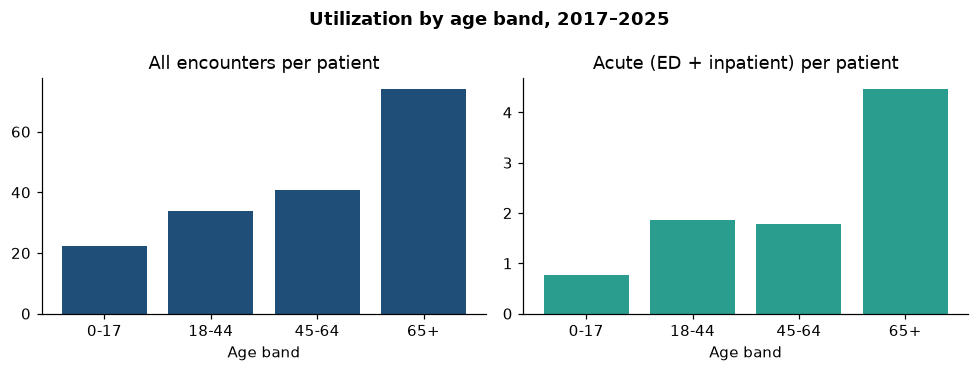

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].bar(by_age["age_band"], by_age["encounters_per_patient"], color=NAVY)
axes[0].set_title("All encounters per patient")
axes[1].bar(by_age["age_band"], by_age["acute_per_patient"], color=TEAL)
axes[1].set_title("Acute (ED + inpatient) per patient")
for ax in axes:
    ax.set_xlabel("Age band")
fig.suptitle("Utilization by age band, 2017–2025", fontweight="bold")
save("utilization_by_age")

Patients 65+ averaged **74 encounters** over the window versus **34** for ages 18–44, about 2.2 times as many. The gap is wider for acute care: **4.5** acute encounters per patient at 65+ against **1.9** for 18–44.

#### Q6. Which disorders are most common among the highest utilizers?

High utilizers are the top 10% of the cohort by encounter count. Prevalence is compared with everyone else to show which disorders are over-represented, not just common.

In [30]:
q("""
    WITH per_patient AS (
        SELECT c.patient_id, COUNT(e.encounter_id) AS encounters
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id
    ),
    deciles AS (
        SELECT patient_id, NTILE(10) OVER (ORDER BY encounters DESC) AS decile
        FROM per_patient
    ),
    groups AS (
        SELECT patient_id, CASE WHEN decile = 1 THEN 'top_10pct' ELSE 'rest' END AS grp
        FROM deciles
    ),
    patient_disorders AS (
        SELECT DISTINCT PATIENT AS patient_id, DESCRIPTION AS disorder
        FROM conditions
        WHERE DESCRIPTION LIKE '%(disorder)'
          AND START <= '2025-12-31'
    )
    SELECT d.disorder,
           ROUND(100.0 * SUM(g.grp = 'top_10pct') / (SELECT COUNT(*) FROM groups WHERE grp = 'top_10pct'), 1) AS pct_top_10,
           ROUND(100.0 * SUM(g.grp = 'rest')      / (SELECT COUNT(*) FROM groups WHERE grp = 'rest'), 1)      AS pct_rest
    FROM patient_disorders d
    JOIN groups g ON g.patient_id = d.patient_id
    GROUP BY d.disorder
    HAVING SUM(g.grp = 'top_10pct') >= 20
    ORDER BY pct_top_10 - pct_rest DESC
    LIMIT 10
""")

,disorder,pct_top_10,pct_rest
0,Disorder of kidney due to diabetes mellitus (disorder),43.3,4.5
1,Chronic kidney disease stage 1 (disorder),42.3,3.5
2,Microalbuminuria due to type 2 diabetes mellitus (disorder),40.4,2.8
3,Chronic kidney disease stage 2 (disorder),38.5,2.0
4,Proteinuria due to type 2 diabetes mellitus (disorder),33.7,1.4
5,Chronic kidney disease stage 3 (disorder),31.7,0.8
6,Essential hypertension (disorder),45.2,16.0
7,Metabolic syndrome X (disorder),36.5,10.6
8,Gingival disease (disorder),63.5,39.4
9,Anemia (disorder),51.9,28.2


The disorders most over-represented among high utilizers are chronic: kidney disease, diabetic kidney complications, hypertension, and metabolic syndrome. Chronic kidney disease stage 3, for example, appears in 32% of high utilizers and under 1% of everyone else. Q10 tests chronic-condition groups directly.

#### Q7. What does an encounter cost, by class?

In [31]:
cost_sql = q("""
    SELECT encounter_class,
           COUNT(*)                  AS encounters,
           ROUND(AVG(claim_cost), 0) AS mean_cost
    FROM v_encounters
    GROUP BY encounter_class
""")
medians = (q("SELECT encounter_class, claim_cost FROM v_encounters")
           .groupby("encounter_class")["claim_cost"].median().round(0).rename("median_cost"))
cost_table = cost_sql.merge(medians, on="encounter_class").sort_values("mean_cost", ascending=False)
cost_table["mean_to_median"] = (cost_table["mean_cost"] / cost_table["median_cost"]).round(1)
cost_table

,encounter_class,encounters,mean_cost,median_cost,mean_to_median
4,inpatient,512,30218.0,14101.0,2.1
6,snf,110,16172.0,11042.0,1.5
3,hospice,59,12613.0,11023.0,1.1
0,ambulatory,21807,4087.0,1460.0,2.8
1,emergency,1504,3095.0,847.0,3.7
5,outpatient,5855,1621.0,722.0,2.2
7,urgentcare,1805,1595.0,925.0,1.7
9,wellness,7939,1209.0,952.0,1.3
2,home,201,768.0,620.0,1.2
8,virtual,110,312.0,125.0,2.5


In [32]:
los = q("SELECT duration_hours / 24.0 AS days FROM v_encounters WHERE encounter_class = 'inpatient'")["days"]
print(f"Inpatient length of stay: median {los.median():.1f} days, mean {los.mean():.1f} days, n = {len(los)}")

Inpatient length of stay: median 4.0 days, mean 5.0 days, n = 512


Inpatient stays have the highest synthetic cost by far. Emergency visits show the biggest gap between mean and median: a small number of very expensive visits pull the mean to about 3.7 times the median, so the median is the better "typical visit" figure.

#### Q8. How much of the cost does the payer cover, by class?

In [33]:
q("""
    SELECT encounter_class,
           ROUND(SUM(claim_cost))                                   AS total_cost,
           ROUND(SUM(payer_coverage))                               AS payer_paid,
           ROUND(SUM(claim_cost) - SUM(payer_coverage))             AS patient_share,
           ROUND(100.0 * SUM(payer_coverage) / SUM(claim_cost), 1)  AS payer_pct
    FROM v_encounters
    GROUP BY encounter_class
    ORDER BY total_cost DESC
""")

,encounter_class,total_cost,payer_paid,patient_share,payer_pct
0,ambulatory,89134578.0,67859015.0,21275563.0,76.1
1,inpatient,15471447.0,10666733.0,4804714.0,68.9
2,wellness,9598733.0,4485324.0,5113409.0,46.7
3,outpatient,9492151.0,6279649.0,3212502.0,66.2
4,emergency,4654482.0,3442777.0,1211704.0,74.0
5,urgentcare,2879848.0,2254958.0,624889.0,78.3
6,snf,1778957.0,1280477.0,498480.0,72.0
7,hospice,744157.0,613666.0,130491.0,82.5
8,home,154283.0,120290.0,33993.0,78.0
9,virtual,34276.0,22321.0,11955.0,65.1


Payers covered 72% of synthetic encounter cost overall. Wellness visits stand out at about 47% coverage, the lowest of any major class.

---
### Advanced

#### Q9. How often do patients return for acute care within 30 days?

**Definition used** (an operational measure, not a CMS readmission rate):
- **Index event:** an emergency or inpatient encounter. Encounters that start before the previous acute encounter ended (ICU transfers, ED-to-admission) are part of the same episode and are not new index events.
- **Return:** another emergency or inpatient encounter starting after the index encounter ends and within 30 days.
- Index events ending after 2025-12-01 are excluded, because their 30-day follow-up falls outside the data.

In [34]:
returns = q("""
    WITH acute AS (
        SELECT patient_id, encounter_id, encounter_class, start_ts, stop_ts,
               LAG(stop_ts) OVER (PARTITION BY patient_id ORDER BY start_ts) AS prev_stop
        FROM v_encounters
        WHERE is_acute = 1
    ),
    index_events AS (
        SELECT *
        FROM acute
        WHERE (prev_stop IS NULL OR julianday(start_ts) >= julianday(prev_stop))
          AND date(stop_ts) <= '2025-12-01'
    ),
    flagged AS (
        SELECT i.encounter_class,
               EXISTS (
                   SELECT 1 FROM v_encounters r
                   WHERE r.patient_id = i.patient_id
                     AND r.is_acute = 1
                     AND julianday(r.start_ts) >  julianday(i.stop_ts)
                     AND julianday(r.start_ts) <= julianday(i.stop_ts) + 30
               ) AS returned
        FROM index_events i
    )
    SELECT encounter_class AS index_type,
           COUNT(*) AS index_events,
           SUM(returned) AS returns_30d,
           ROUND(100.0 * AVG(returned), 1) AS return_rate_pct
    FROM flagged GROUP BY encounter_class
    UNION ALL
    SELECT 'all acute', COUNT(*), SUM(returned), ROUND(100.0 * AVG(returned), 1) FROM flagged
""")
returns

,index_type,index_events,returns_30d,return_rate_pct
0,emergency,1487,226,15.2
1,inpatient,427,122,28.6
2,all acute,1914,348,18.2


About **18%** of acute episodes were followed by another acute encounter within 30 days. The rate after an inpatient stay (**29%**) was nearly double the rate after an emergency visit (**15%**).

#### Q10. Which chronic-condition groups are associated with higher utilization?

A patient-level flag table is built first (one row per patient, one column per group) and then joined to per-patient encounter counts. Joining conditions straight to encounters would multiply rows (see Part 1).

Patients with chronic conditions are also older, so the comparison is repeated inside a single age band (45–64) to separate the condition from age.

In [35]:
FLAGS = """
    WITH flags AS (
        SELECT PATIENT AS patient_id,
               MAX(DESCRIPTION LIKE '%hypertension%')                                         AS hypertension,
               MAX(DESCRIPTION LIKE '%diabetes%' AND DESCRIPTION NOT LIKE 'Prediabetes%')     AS diabetes,
               MAX(DESCRIPTION LIKE '%chronic kidney disease%')                               AS chronic_kidney_disease,
               MAX(DESCRIPTION LIKE '%chronic obstructive%' OR DESCRIPTION LIKE '%emphysema%') AS copd,
               MAX(DESCRIPTION LIKE '%asthma%')                                               AS asthma,
               MAX(DESCRIPTION LIKE 'Body mass index 30+%')                                   AS obesity,
               MAX(DESCRIPTION LIKE 'Chronic pain%')                                          AS chronic_pain
        FROM conditions
        WHERE START <= '2025-12-31'
        GROUP BY PATIENT
    ),
    per_patient AS (
        SELECT c.patient_id, c.age, c.age_band,
               COUNT(e.encounter_id)        AS encounters,
               COALESCE(SUM(e.is_acute), 0) AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id
    )
"""
GROUPS = ["hypertension", "diabetes", "chronic_kidney_disease", "copd", "asthma", "obesity", "chronic_pain"]

def compare(group, where="1 = 1"):
    return q(FLAGS + f"""
        SELECT '{group}' AS condition_group,
               COALESCE(f.{group}, 0)   AS has_condition,
               COUNT(*)                 AS patients,
               ROUND(AVG(p.encounters), 1) AS encounters_per_patient,
               ROUND(AVG(p.acute), 2)   AS acute_per_patient,
               ROUND(AVG(p.age), 0)     AS avg_age
        FROM per_patient p
        LEFT JOIN flags f ON f.patient_id = p.patient_id
        WHERE {where}
        GROUP BY has_condition
    """)

overall = pd.concat([compare(g) for g in GROUPS])
overall_wide = overall.pivot(index="condition_group", columns="has_condition",
                             values=["patients", "encounters_per_patient", "acute_per_patient", "avg_age"])
overall_wide.columns = [f"{m}_{'with' if f else 'without'}" for m, f in overall_wide.columns]
overall_wide["encounter_ratio"] = (overall_wide["encounters_per_patient_with"] /
                                   overall_wide["encounters_per_patient_without"]).round(1)
overall_wide.sort_values("encounter_ratio", ascending=False)[
    ["patients_with", "encounters_per_patient_with", "encounters_per_patient_without",
     "encounter_ratio", "acute_per_patient_with", "acute_per_patient_without",
     "avg_age_with", "avg_age_without"]]

,patients_with,encounters_per_patient_with,encounters_per_patient_without,encounter_ratio,acute_per_patient_with,acute_per_patient_without,avg_age_with,avg_age_without
condition_group,,,,,,,,
chronic_kidney_disease,81.0,144.2,29.6,4.9,5.36,1.66,65.0,36.0
diabetes,128.0,107.1,28.9,3.7,4.86,1.54,65.0,34.0
hypertension,196.0,74.6,30.2,2.5,3.54,1.58,60.0,33.0
obesity,445.0,48.6,31.0,1.6,2.49,1.54,56.0,25.0
chronic_pain,261.0,49.0,35.1,1.4,3.40,1.46,48.0,35.0
asthma,59.0,48.8,38.0,1.3,3.00,1.89,31.0,39.0
copd,25.0,51.2,38.3,1.3,4.04,1.90,60.0,38.0


For five of the seven groups, patients with the condition are 20–30 years older on average than those without, so part of each gap is age. Holding age roughly constant:

In [36]:
mid = pd.concat([compare(g, "p.age_band = '45-64'") for g in GROUPS])
mid_wide = mid.pivot(index="condition_group", columns="has_condition",
                     values=["patients", "encounters_per_patient", "acute_per_patient"])
mid_wide.columns = [f"{m}_{'with' if f else 'without'}" for m, f in mid_wide.columns]
mid_wide["encounter_ratio"] = (mid_wide["encounters_per_patient_with"] /
                               mid_wide["encounters_per_patient_without"]).round(1)
mid_wide = mid_wide.sort_values("encounter_ratio", ascending=False)
mid_wide[["patients_with", "encounters_per_patient_with", "encounters_per_patient_without",
          "encounter_ratio", "acute_per_patient_with", "acute_per_patient_without"]]

,patients_with,encounters_per_patient_with,encounters_per_patient_without,encounter_ratio,acute_per_patient_with,acute_per_patient_without
condition_group,,,,,,
chronic_kidney_disease,42.0,97.0,30.4,3.2,2.88,1.58
diabetes,59.0,80.2,29.7,2.7,3.19,1.38
hypertension,90.0,57.0,32.7,1.7,2.07,1.64
chronic_pain,93.0,44.9,38.7,1.2,2.38,1.47
obesity,220.0,41.6,37.5,1.1,1.65,2.38
asthma,9.0,35.1,41.1,0.9,1.67,1.79
copd,11.0,35.6,41.1,0.9,2.27,1.76


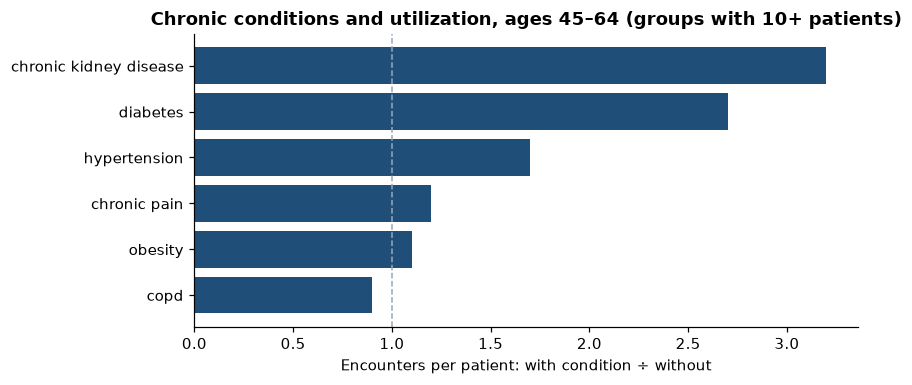

In [37]:
plot = mid_wide[mid_wide["patients_with"] >= 10].sort_values("encounter_ratio")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(plot.index.str.replace("_", " "), plot["encounter_ratio"], color=NAVY)
ax.axvline(1, color=GREY, linestyle="--", linewidth=1)
ax.set_xlabel("Encounters per patient: with condition ÷ without")
ax.set_title("Chronic conditions and utilization, ages 45–64 (groups with 10+ patients)", fontweight="bold")
save("chronic_conditions_45_64")

Even within the 45–64 band, patients with **chronic kidney disease** had about **3.2 times** as many encounters as those without, and patients with **diabetes** about **2.7 times**. They also had roughly twice the acute encounters. Some of the extra volume is scheduled monitoring that Synthea builds into chronic-disease care plans, so these are associations in a simulation, not evidence that the condition causes the use.

#### Q11. Who are the top utilizers within each age band?

A single overall ranking would be dominated by older patients. `DENSE_RANK` with `PARTITION BY` ranks patients within their own age band.

In [38]:
q("""
    WITH per_patient AS (
        SELECT c.patient_id, c.age_band, c.age,
               COUNT(e.encounter_id)                   AS encounters,
               ROUND(COUNT(e.encounter_id) / 9.0, 1)   AS avg_per_year,
               COALESCE(SUM(e.is_acute), 0)            AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id
    ),
    ranked AS (
        SELECT *, DENSE_RANK() OVER (PARTITION BY age_band ORDER BY encounters DESC) AS rank_in_band
        FROM per_patient
    )
    SELECT age_band, rank_in_band, substr(patient_id, 1, 8) AS patient, age, encounters, avg_per_year, acute
    FROM ranked
    WHERE rank_in_band <= 3
    ORDER BY age_band, rank_in_band
""")

,age_band,rank_in_band,patient,age,encounters,avg_per_year,acute
0,0-17,1,c6fe6252,17,98,10.9,3
1,0-17,2,fb8dece5,16,91,10.1,1
2,0-17,3,aa3310ee,17,86,9.6,0
3,18-44,1,8c5fa9a2,44,535,59.4,14
4,18-44,2,355d5f82,43,498,55.3,3
5,18-44,3,9255b577,18,118,13.1,4
6,45-64,1,ee3b5fff,52,426,47.3,1
7,45-64,2,64b4fd5b,61,391,43.4,5
8,45-64,3,e0c3d2cf,55,385,42.8,2
9,65+,1,92819b94,109,640,71.1,3


Patient IDs are shortened for display. `avg_per_year` divides by the nine-year window, so it understates the rate for patients born or deceased during it.

#### Q12. How did encounter volume change year over year?

In [39]:
yoy = q("""
    WITH yearly AS (
        SELECT year, COUNT(*) AS encounters
        FROM v_encounters
        GROUP BY year
    )
    SELECT year,
           encounters,
           LAG(encounters) OVER (ORDER BY year)                              AS prior_year,
           encounters - LAG(encounters) OVER (ORDER BY year)                 AS change,
           ROUND(100.0 * (encounters - LAG(encounters) OVER (ORDER BY year))
                 / LAG(encounters) OVER (ORDER BY year), 1)                  AS pct_change
    FROM yearly
    ORDER BY year
""")
yoy

,year,encounters,prior_year,change,pct_change
0,2017,4081,NaN,NaN,NaN
1,2018,3998,4081.0,-83.0,-2.0
2,2019,4034,3998.0,36.0,0.9
3,2020,4188,4034.0,154.0,3.8
4,2021,5334,4188.0,1146.0,27.4
5,2022,3990,5334.0,-1344.0,-25.2
6,2023,4553,3990.0,563.0,14.1
7,2024,4767,4553.0,214.0,4.7
8,2025,4957,4767.0,190.0,4.0


In [40]:
q("""
    SELECT year, description, COUNT(*) AS encounters
    FROM v_encounters
    WHERE encounter_class = 'outpatient' AND year BETWEEN 2020 AND 2022
    GROUP BY year, description
    HAVING COUNT(*) >= 100
    ORDER BY year, encounters DESC
""")

,year,description,encounters
0,2020,Encounter for check up (procedure),238
1,2020,Patient encounter procedure (procedure),135
2,2020,Consultation for treatment (procedure),110
3,2021,Administration of vaccine to produce active immunity (procedure),1213
4,2021,Encounter for check up (procedure),255
5,2021,Patient encounter procedure (procedure),134
6,2021,Consultation for treatment (procedure),107
7,2022,Encounter for check up (procedure),228
8,2022,Patient encounter procedure (procedure),114


The 2021 jump (+27%) and the 2022 drop (−25%) come almost entirely from about 1,200 outpatient **vaccine administration** encounters in 2021. Synthea's immunizations file, which is not one of the six tables in this project, shows these as COVID-19 mRNA doses. Without that one-off, 2017–2025 volume is broadly flat with gradual growth.

#### Q13. How concentrated is utilization?

In [41]:
conc = q("""
    WITH per_patient AS (
        SELECT c.patient_id,
               COUNT(e.encounter_id)              AS encounters,
               COALESCE(SUM(e.is_acute), 0)       AS acute,
               COALESCE(SUM(e.claim_cost), 0)     AS cost
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id
    ),
    deciles AS (
        SELECT *,
               NTILE(10) OVER (ORDER BY encounters DESC) AS enc_decile,
               NTILE(10) OVER (ORDER BY acute DESC)      AS acute_decile
        FROM per_patient
    )
    SELECT enc_decile AS decile,
           ROUND(100.0 * SUM(encounters) / (SELECT SUM(encounters) FROM per_patient), 1) AS pct_of_encounters,
           ROUND(100.0 * SUM(cost)       / (SELECT SUM(cost)       FROM per_patient), 1) AS pct_of_cost,
           (SELECT ROUND(100.0 * SUM(acute) / (SELECT SUM(acute) FROM per_patient), 1)
              FROM deciles d2 WHERE d2.acute_decile = deciles.enc_decile)             AS pct_of_acute_by_acute_decile
    FROM deciles
    GROUP BY enc_decile
    ORDER BY enc_decile
""")
conc

,decile,pct_of_encounters,pct_of_cost,pct_of_acute_by_acute_decile
0,1,37.9,35.5,52.1
1,2,13.9,23.8,16.6
2,3,10.7,13.8,11.0
3,4,8.6,9.5,7.6
4,5,7.2,5.1,5.1
5,6,6.1,3.7,5.1
6,7,5.4,3.1,2.5
7,8,4.5,2.6,0.0
8,9,3.5,1.8,0.0
9,10,2.0,1.1,0.0


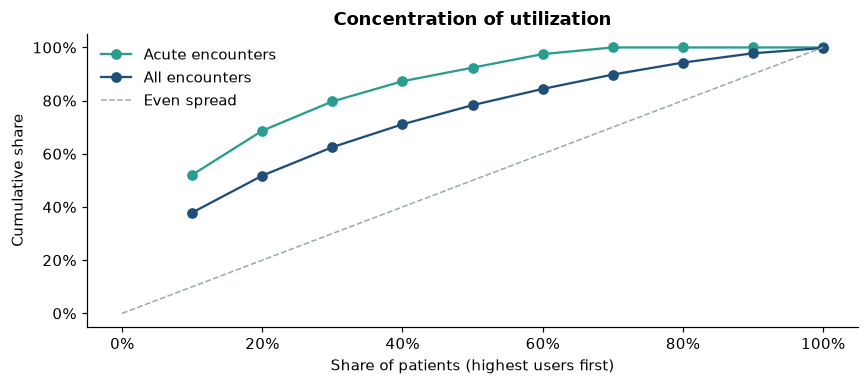

In [42]:
fig, ax = plt.subplots(figsize=(8, 3.6))
cum_enc = conc["pct_of_encounters"].cumsum()
cum_acute = conc["pct_of_acute_by_acute_decile"].cumsum()
x = conc["decile"] * 10
ax.plot(x, cum_acute, marker="o", color=TEAL, label="Acute encounters")
ax.plot(x, cum_enc, marker="o", color=NAVY, label="All encounters")
ax.plot([0, 100], [0, 100], color=GREY, linestyle="--", linewidth=1, label="Even spread")
ax.set_xlabel("Share of patients (highest users first)")
ax.set_ylabel("Cumulative share")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Concentration of utilization", fontweight="bold")
ax.legend(frameon=False)
save("concentration")

The top 10% of patients account for **38%** of all encounters and **36%** of synthetic cost. Acute care is more concentrated still: the top 10% of acute users account for **52%** of all ED and inpatient encounters.

#### Q14. How do volume and cost relate across encounter classes?

In [43]:
mix = q("""
    SELECT encounter_class,
           ROUND(100.0 * COUNT(*)        / SUM(COUNT(*))        OVER (), 1) AS pct_of_encounters,
           ROUND(100.0 * SUM(claim_cost) / SUM(SUM(claim_cost)) OVER (), 1) AS pct_of_cost
    FROM v_encounters
    GROUP BY encounter_class
    ORDER BY pct_of_cost DESC
""")
mix

,encounter_class,pct_of_encounters,pct_of_cost
0,ambulatory,54.7,66.5
1,inpatient,1.3,11.6
2,wellness,19.9,7.2
3,outpatient,14.7,7.1
4,emergency,3.8,3.5
5,urgentcare,4.5,2.2
6,snf,0.3,1.3
7,hospice,0.1,0.6
8,home,0.5,0.1
9,virtual,0.3,0.0


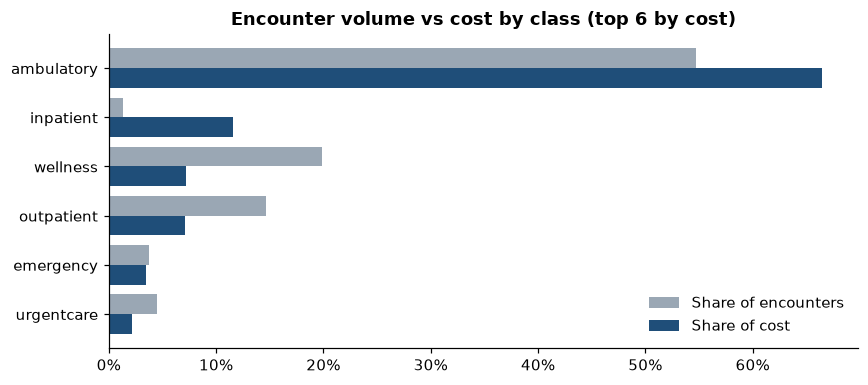

In [44]:
top = mix.head(6).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = range(len(top))
ax.barh([i + 0.2 for i in y], top["pct_of_encounters"], height=0.4, color=GREY, label="Share of encounters")
ax.barh([i - 0.2 for i in y], top["pct_of_cost"], height=0.4, color=NAVY, label="Share of cost")
ax.set_yticks(list(y))
ax.set_yticklabels(top["encounter_class"])
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Encounter volume vs cost by class (top 6 by cost)", fontweight="bold")
ax.legend(frameon=False)
save("volume_vs_cost")

Inpatient stays are about 1% of encounters but about 12% of synthetic cost. Wellness visits run the other way: roughly 20% of encounters for about 7% of cost.

---
## Part 4 · Key Findings

All figures describe the synthetic Synthea cohort (1,034 patients, 39,902 encounters, 2017–2025).

1. **Age drives volume, and acute care even more.** Patients 65+ averaged 74 encounters over the window versus 34 for ages 18–44, and 4.5 acute encounters versus 1.9.
2. **Acute care is concentrated.** The top 10% of acute users account for 52% of all ED and inpatient encounters. The top 10% overall account for 38% of all encounters.
3. **Inpatient stays carry the cost.** About 1% of encounters, about 12% of synthetic cost, median stay 4 days.
4. **Returns after hospital stays are common.** 29% of inpatient episodes were followed by another acute encounter within 30 days, versus 15% after an emergency visit.
5. **Chronic kidney disease and diabetes stand out.** Within ages 45–64, patients with CKD had about 3.2 times the encounters of those without, and patients with diabetes about 2.7 times.

Data-quality notes that shaped these results: Death Certification records excluded; 2017–2025 window chosen from coverage; a one-off 2021 vaccination surge explained rather than treated as a trend.

#### Q15. Does acute care use differ between women and men?

In [45]:
con = sqlite3.connect(DB)   # reopen the database in case it was closed

q("""
    SELECT gender, COUNT(*) AS patients
    FROM v_cohort
    GROUP BY gender
""")

,gender,patients
0,F,539
1,M,495


In [46]:
by_gender = q("""
    WITH per_patient AS (
        SELECT c.patient_id, c.gender, c.age_band,
               COUNT(e.encounter_id)        AS encounters,
               COALESCE(SUM(e.is_acute), 0) AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id, c.gender, c.age_band
    )
    SELECT gender,
           COUNT(*)                  AS patients,
           ROUND(AVG(encounters), 1) AS encounters_per_patient,
           ROUND(AVG(acute), 2)      AS acute_per_patient
    FROM per_patient
    GROUP BY gender
""")
by_gender

,gender,patients,encounters_per_patient,acute_per_patient
0,F,539,45.8,2.29
1,M,495,30.7,1.58


In [47]:
by_gender = q("""
    WITH per_patient AS (
        SELECT c.patient_id, c.gender, c.age_band,
               COUNT(e.encounter_id)        AS encounters,
               COALESCE(SUM(e.is_acute), 0) AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id, c.gender, c.age_band
    )
    SELECT gender,
           COUNT(*)                  AS patients,
           ROUND(AVG(encounters), 1) AS encounters_per_patient,
           ROUND(AVG(acute), 2)      AS acute_per_patient
    FROM per_patient
    GROUP BY gender
""")
by_gender

,gender,patients,encounters_per_patient,acute_per_patient
0,F,539,45.8,2.29
1,M,495,30.7,1.58


gender,F,M
age_band,,
0-17,0.80,0.72
18-44,2.64,1.13
45-64,1.68,1.90
65+,4.78,4.02


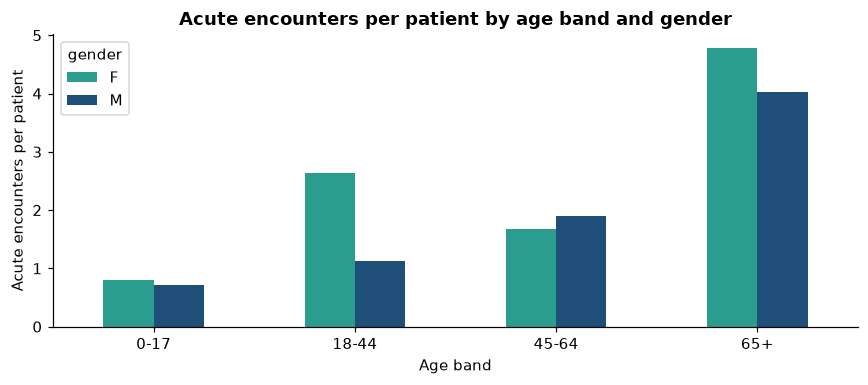

In [48]:
by_age_gender = q("""
    WITH per_patient AS (
        SELECT c.patient_id, c.gender, c.age_band,
               COALESCE(SUM(e.is_acute), 0) AS acute
        FROM v_cohort c
        LEFT JOIN v_encounters e ON e.patient_id = c.patient_id
        GROUP BY c.patient_id, c.gender, c.age_band
    )
    SELECT age_band, gender, ROUND(AVG(acute), 2) AS acute_per_patient
    FROM per_patient
    GROUP BY age_band, gender
    ORDER BY age_band, gender
""")

table = by_age_gender.pivot(index="age_band", columns="gender", values="acute_per_patient")
display(table)

table.plot(kind="bar", color=[TEAL, NAVY], figsize=(8, 3.6), rot=0)
plt.title("Acute encounters per patient by age band and gender", fontweight="bold")
plt.ylabel("Acute encounters per patient")
plt.xlabel("Age band")
save("acute_by_gender")

In [49]:
q("""
    SELECT c.gender, e.encounter_class, e.description, COUNT(*) AS acute_encounters
    FROM v_encounters e
    JOIN v_cohort c ON c.patient_id = e.patient_id
    WHERE e.is_acute = 1
      AND c.age_band = '18-44'
    GROUP BY c.gender, e.encounter_class, e.description
    ORDER BY acute_encounters DESC
    LIMIT 10
""")

,gender,encounter_class,description,acute_encounters
0,F,emergency,Obstetric emergency hospital admission (procedure),200
1,F,emergency,Emergency room admission (procedure),181
2,M,emergency,Emergency room admission (procedure),154
3,F,emergency,Emergency hospital admission (procedure),35
4,F,inpatient,Admission to surgical department (procedure),24
5,M,emergency,Emergency hospital admission for asthma (procedure),20
6,F,emergency,Emergency hospital admission for asthma (procedure),17
7,F,emergency,Encounter for symptom (procedure),16
8,F,inpatient,Drug rehabilitation and detoxification (regime/therapy),16
9,M,inpatient,Drug rehabilitation and detoxification (regime/therapy),16
